In [1]:
# Import relevant modules
import pandas as pd
import numpy as np
import matplotlib as plt
from datetime import datetime 

### Merging Datasets

##### This merges the climatological snowfall with the current year to date snowfall to help produce the plots later on.

In [2]:
# copy in the downloaded .csv file paths
normal = pd.read_csv("Snowfall_Normals_1991-2020_Oct1-Mar31.csv")
thisyear=pd.read_csv("0331_NYS_Snowfall.csv")
thisyear


,Name,StationType,Longitude,Latitude,Elevation,TotalSnowfall,mcnt
0,BRIDGEHAMPTON,COOP,-72.298,40.952,42,8.1,9
1,ISLIP-LI MACARTHUR AP,WBAN,-73.102,40.794,83,11.7,1
2,LAGUARDIA AIRPORT,WBAN,-73.88,40.779,10,15.4,1
3,NY CITY CENTRAL PARK,WBAN,-73.969,40.779,140,12.9,1
4,RIVERHEAD RESEARCH FARM,COOP,-72.716,40.962,100,10.5,1
...,...,...,...,...,...,...,...
622,SPRINGVILLE 1.1 WNW,CoCoRaHS,-78.688,42.517,1463,M,35
623,CAYUGA 0.4 N,CoCoRaHS,-76.729,42.925,390,M,123
624,NELSONVILLE 0.3 S,CoCoRaHS,-73.948,41.425,199,M,59
625,ITHACA 3.4 SE,CoCoRaHS,-76.449,42.415,887,M,117


In [3]:
normal


,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,YTD-SNOW-NORMAL,Unnamed: 7,0,CUMULATIVE_SNOW_NORMAL
0,USC00304808,"LITTLE VALLEY, NY US",42.2472,-78.8125,495.3,30-Sep,84.9,NaN,NaN,84.9
1,USC00304808,"LITTLE VALLEY, NY US",42.2472,-78.8125,495.3,1-Oct,84.9,NaN,NaN,0.0
2,USC00304808,"LITTLE VALLEY, NY US",42.2472,-78.8125,495.3,2-Oct,84.9,NaN,NaN,0.0
3,USC00304808,"LITTLE VALLEY, NY US",42.2472,-78.8125,495.3,3-Oct,84.9,NaN,NaN,0.0
4,USC00304808,"LITTLE VALLEY, NY US",42.2472,-78.8125,495.3,4-Oct,84.9,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...
19027,USC00305925,"N CREEK 5 SE, NY US",43.6611,-73.8969,271.3,27-Mar,49.9,NaN,NaN,72.1
19028,USC00305925,"N CREEK 5 SE, NY US",43.6611,-73.8969,271.3,28-Mar,50.2,NaN,NaN,72.4
19029,USC00305925,"N CREEK 5 SE, NY US",43.6611,-73.8969,271.3,29-Mar,50.5,NaN,NaN,72.7
19030,USC00305925,"N CREEK 5 SE, NY US",43.6611,-73.8969,271.3,30-Mar,50.8,NaN,NaN,73.0


In [4]:
# If after March 31st
from datetime import datetime

# Set 'Today' to March 31st and format it as "31-Mar"
Today = datetime(datetime.now().year, 3, 31).strftime("%d-%b")

print(Today)  # Output: 31-Mar


31-Mar


In [5]:
# Get today's date (month and day only) Comment out the today code if before March 31st and and October 1st
today = datetime(datetime.now().year, 3, 31).strftime("%d-%b")
print(today)
#today = datetime.today().strftime('%-d-%b')  # uncomment if above line is commented
today_normal = normal[normal['DATE'] == today]
today_normal

31-Mar


,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,YTD-SNOW-NORMAL,Unnamed: 7,0,CUMULATIVE_SNOW_NORMAL
182,USC00304808,"LITTLE VALLEY, NY US",42.2472,-78.8125,495.3,31-Mar,80.9,NaN,NaN,129.3
365,USC00303955,"HONEOYE, NY US",42.7914,-77.5133,243.8,31-Mar,39.1,NaN,NaN,53.1
548,USW00014735,"ALBANY AP, NY US",42.7431,-73.8092,95.1,31-Mar,41.3,NaN,NaN,57.5
731,USC00300443,"BATAVIA, NY US",43.0297,-78.1683,278.3,31-Mar,53.0,NaN,NaN,72.2
914,USC00304647,"LAWRENCEVILLE 3 SW, NY US",44.7583,-74.6692,142.0,31-Mar,48.2,NaN,NaN,70.1
...,...,...,...,...,...,...,...,...,...,...
18299,USC00304555,"LAKE PLACID 2 S, NY US",44.3042,-73.9839,575.5,31-Mar,60.9,NaN,NaN,95.8
18482,USC00300085,"ALFRED, NY US",42.2797,-77.7656,586.4,31-Mar,53.6,NaN,NaN,78.4
18665,USC00308910,"WALES, NY US",42.7392,-78.5878,345.9,31-Mar,69.8,NaN,NaN,105.7
18848,USC00307705,"SHERBURNE, NY US",42.6772,-75.5067,333.8,31-Mar,52.1,NaN,NaN,74.5


In [6]:
# Identify Column Names
thisyear["DATE"]= today

col=thisyear.columns
print(col)

Index(['Name', ' StationType', ' Longitude', ' Latitude', ' Elevation',
       ' TotalSnowfall', ' mcnt', 'DATE'],
      dtype='object')


In [7]:
# Puts names into proper format in a new column
today_normal['Name'] = today_normal['NAME'].str.split(',').str[0].str.strip()
today_normal

/tmp/ipykernel_450272/936284654.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  today_normal['Name'] = today_normal['NAME'].str.split(',').str[0].str.strip()


,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,YTD-SNOW-NORMAL,Unnamed: 7,0,CUMULATIVE_SNOW_NORMAL,Name
182,USC00304808,"LITTLE VALLEY, NY US",42.2472,-78.8125,495.3,31-Mar,80.9,NaN,NaN,129.3,LITTLE VALLEY
365,USC00303955,"HONEOYE, NY US",42.7914,-77.5133,243.8,31-Mar,39.1,NaN,NaN,53.1,HONEOYE
548,USW00014735,"ALBANY AP, NY US",42.7431,-73.8092,95.1,31-Mar,41.3,NaN,NaN,57.5,ALBANY AP
731,USC00300443,"BATAVIA, NY US",43.0297,-78.1683,278.3,31-Mar,53.0,NaN,NaN,72.2,BATAVIA
914,USC00304647,"LAWRENCEVILLE 3 SW, NY US",44.7583,-74.6692,142.0,31-Mar,48.2,NaN,NaN,70.1,LAWRENCEVILLE 3 SW
...,...,...,...,...,...,...,...,...,...,...,...
18299,USC00304555,"LAKE PLACID 2 S, NY US",44.3042,-73.9839,575.5,31-Mar,60.9,NaN,NaN,95.8,LAKE PLACID 2 S
18482,USC00300085,"ALFRED, NY US",42.2797,-77.7656,586.4,31-Mar,53.6,NaN,NaN,78.4,ALFRED
18665,USC00308910,"WALES, NY US",42.7392,-78.5878,345.9,31-Mar,69.8,NaN,NaN,105.7,WALES
18848,USC00307705,"SHERBURNE, NY US",42.6772,-75.5067,333.8,31-Mar,52.1,NaN,NaN,74.5,SHERBURNE


In [8]:
#merges dataframes
merged_df= pd.merge(today_normal, thisyear, on="Name")


# Remove leading/trailing spaces in column names (if any)
merged_df = merged_df.rename(columns=lambda x: x.strip())

# Convert columns to numeric, forcing errors='coerce' to handle non-numeric values
merged_df['TotalSnowfall'] = pd.to_numeric(merged_df['TotalSnowfall'], errors='coerce')
merged_df['CUMULATIVE_SNOW_NORMAL'] = pd.to_numeric(merged_df['CUMULATIVE_SNOW_NORMAL'], errors='coerce')

# Perform the subtraction
merged_df['Snowfall Anomaly'] = merged_df['TotalSnowfall'] - merged_df['CUMULATIVE_SNOW_NORMAL']
merged_df['Percent Snowfall Anomaly'] = ((merged_df['TotalSnowfall'] - merged_df['CUMULATIVE_SNOW_NORMAL']) / merged_df['CUMULATIVE_SNOW_NORMAL']) * 100 

# Remove rows where 'Snowfall Anomaly' is NaN
#merged_df = merged_df.dropna(subset=['Snowfall Anomaly'])

print(merged_df)
#merged_df.to_csv("Merged Snowfall.csv")
#print(merged_df)

        STATION                             NAME  LATITUDE  LONGITUDE  \
0   USC00304808             LITTLE VALLEY, NY US   42.2472   -78.8125   
1   USC00303955                   HONEOYE, NY US   42.7914   -77.5133   
2   USC00300443                   BATAVIA, NY US   43.0297   -78.1683   
3   USC00300321                    AUBURN, NY US   42.9328   -76.5447   
4   USC00307484     SARATOGA SPRINGS 4 SW, NY US   43.0411   -73.8211   
5   USC00301787                   CORNING, NY US   42.1342   -77.0692   
6   USW00014743               CANTON 4 SE, NY US   44.5772   -75.1097   
7   USC00303444                    GREENE, NY US   42.3239   -75.7711   
8   USC00303961             HOOKER 12 NNW, NY US   43.8525   -75.7158   
9   USC00300055                    ALBION, NY US   43.2633   -78.2153   
10  USC00309425            WHITESVILLE 1N, NY US   42.0597   -77.7553   
11  USC00300063                ALCOVE DAM, NY US   42.4697   -73.9267   
12  USC00306314                    OSWEGO, NY US   

### Plotting Total Snowfall

### Year to Date Climatological Normals

ERROR 1: PROJ: proj_create_from_database: Cannot find proj.db


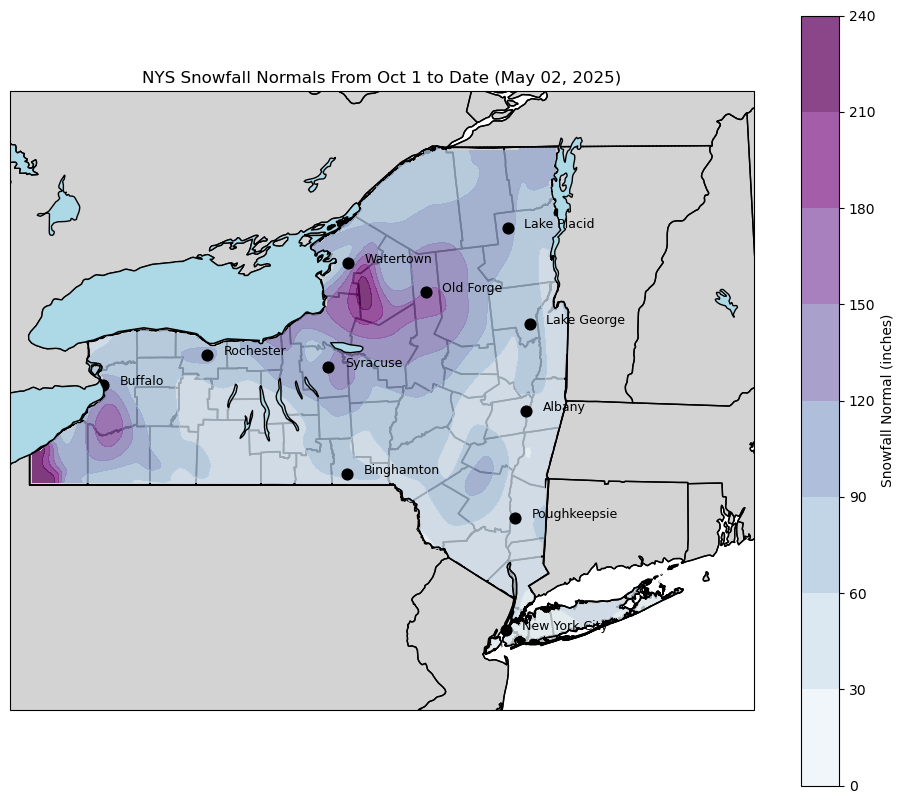

In [9]:
import pandas as pd
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
from shapely.geometry import Point
from matplotlib.ticker import MaxNLocator

# === Load and filter data ===
filtered_df = today_normal  # Ensure this DataFrame is properly defined
filtered_df = filtered_df.dropna(subset=['CUMULATIVE_SNOW_NORMAL'])

# Load NYS shapefile
shapefile_path = 'Counties_Shoreline.shp'
gdf = gpd.read_file(shapefile_path).to_crs("EPSG:4326")  # Ensure correct CRS

# Create GeoDataFrame for snowfall normal data
snowfall_gdf = gpd.GeoDataFrame(
    filtered_df,
    geometry=gpd.points_from_xy(filtered_df.LONGITUDE, filtered_df.LATITUDE),
    crs="EPSG:4326"
)

# Extract coordinates and anomaly values
lats = snowfall_gdf['LATITUDE'].values
lons = snowfall_gdf['LONGITUDE'].values
normals = snowfall_gdf['CUMULATIVE_SNOW_NORMAL'].values

# Define grid for contouring
lon_min, lon_max = -80, -71
lat_min, lat_max = 40, 45.5
lon_grid, lat_grid = np.meshgrid(
    np.linspace(lon_min, lon_max, 200),
    np.linspace(lat_min, lat_max, 200)
)

# Interpolate snowfall normal data
grid_normals_cubic = griddata((lons, lats), normals, (lon_grid, lat_grid), method="cubic")
grid_normals_nearest = griddata((lons, lats), normals, (lon_grid, lat_grid), method="nearest")
grid_normals = np.where(np.isnan(grid_normals_cubic), grid_normals_nearest, grid_normals_cubic)

# Apply Gaussian filter to smooth the interpolated grid
grid_normals_smoothed = gaussian_filter(grid_normals, sigma=1.0)  # Adjust sigma for more/less smoothing

# === Mask areas outside NYS ===
mask = np.zeros(grid_normals_smoothed.shape, dtype=bool)

# Iterate over NYS polygons to apply mask
for geom in gdf.geometry:
    for i, (lon, lat) in enumerate(zip(lon_grid.flatten(), lat_grid.flatten())):
        point = Point(lon, lat)
        if geom.contains(point):
            mask[np.unravel_index(i, mask.shape)] = True

# Apply the mask to snowfall normal data
grid_normals_smoothed[~mask] = np.nan

# === Plot the snowfall normal contour map ===
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Add shapefile boundary
gdf.plot(ax=ax, edgecolor="black", facecolor="none", linewidth=1.2, transform=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.STATES, edgecolor="black")
ax.add_feature(cfeature.COASTLINE, edgecolor="black")
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.LAKES, edgecolor="black", facecolor="lightblue")

# Define contour levels
levels = np.arange(0, np.nanmax(grid_normals_smoothed) + 30, 30)

# Contour plot of smoothed snowfall normal data (masked)
contour = ax.contourf(lon_grid, lat_grid, grid_normals_smoothed, levels=levels, cmap="BuPu", alpha=0.75)

# Create a colorbar
cbar = plt.colorbar(contour, ax=ax, orientation="vertical", label="Snowfall Normal (inches)")
cbar.set_ticks(levels)  # Set colorbar ticks to match contour intervals

# === Add Cities to the Map ===
cities = {
    "New York City": (-74.0060, 40.7128),
    "Buffalo": (-78.8784, 42.8864),
    "Rochester": (-77.6120, 43.1566),
    "Syracuse": (-76.1474, 43.0481),
    "Albany": (-73.7562, 42.6526),
    "Binghamton": (-75.9179, 42.0987),
    "Lake George": (-73.7145, 43.4291),
    "Lake Placid": (-73.9802, 44.2795),
    "Poughkeepsie": (-73.8931, 41.7096),
    "Old Forge": (-74.9735, 43.7101),
    "Watertown": (-75.9097, 43.9726)
}

for city, (lon, lat) in cities.items():
    ax.scatter(lon, lat, color="black", marker="o", s=60, transform=ccrs.PlateCarree())
    ax.text(lon + 0.2, lat, city, fontsize=9, ha="left", transform=ccrs.PlateCarree())

# Title
ax.set_title(f"NYS Snowfall Normals From Oct 1 to Date ({datetime.now().strftime('%B %d, %Y')})")
# Save the figure before displaying it
plt.savefig("NYS_Snowfall_Normals.png", dpi=300, bbox_inches="tight")
plt.show()


### Plotting Current Year's Snowfall from Oct. 1 to Date

In [10]:
### put in the current year's .csv file again
currentdata= pd.read_csv('0326NYS_Snowfall.csv')

In [11]:
currentdata

,Name,StationType,Longitude,Latitude,Elevation,TotalSnowfall
0,BRIDGEHAMPTON,COOP,-72.298,40.952,42,8.1
1,ISLIP-LI MACARTHUR AP,WBAN,-73.102,40.794,83,11.7
2,LAGUARDIA AIRPORT,WBAN,-73.88,40.779,10,15.4
3,NY CITY CENTRAL PARK,WBAN,-73.969,40.779,140,12.9
4,RIVERHEAD RESEARCH FARM,COOP,-72.716,40.962,100,10.5
...,...,...,...,...,...,...
621,CORNING 2.9 N,CoCoRaHS,-77.065,42.188,1476,M
622,CANANDAIGUA 4.6 S,CoCoRaHS,-77.288,42.822,842,M
623,HOFFMEISTER 2.0 E,CoCoRaHS,-74.677,43.387,1949,M
624,WESTVALE 2.3 SSW,CoCoRaHS,-76.225,43.009,860,M


In [12]:
currentdata[' Longitude']

0      -72.298
1      -73.102
2       -73.88
3      -73.969
4      -72.716
        ...   
621    -77.065
622    -77.288
623    -74.677
624    -76.225
625    -73.873
Name:  Longitude, Length: 626, dtype: object

In [13]:
print(currentdata.columns)

currentdata['Longitude']=currentdata[' Longitude']
currentdata['Latitude']=currentdata[ ' Latitude']
currentdata['TotalSnowfall']=currentdata[' TotalSnowfall']
currentdata['Latitude'] = pd.to_numeric(currentdata["Latitude"], errors="coerce")

currentdata["Longitude"] = pd.to_numeric(currentdata["Longitude"], errors="coerce")
currentdata["Latitude"] = pd.to_numeric(currentdata["Latitude"], errors="coerce")
currentdata["TotalSnowfall"] = pd.to_numeric(currentdata["TotalSnowfall"], errors="coerce")
# Drop rows where Longitude or Latitude is NaN
currentdata = currentdata.dropna(subset=["Longitude", "Latitude", "TotalSnowfall"])


Index(['Name', ' StationType', ' Longitude', ' Latitude', ' Elevation',
       ' TotalSnowfall'],
      dtype='object')


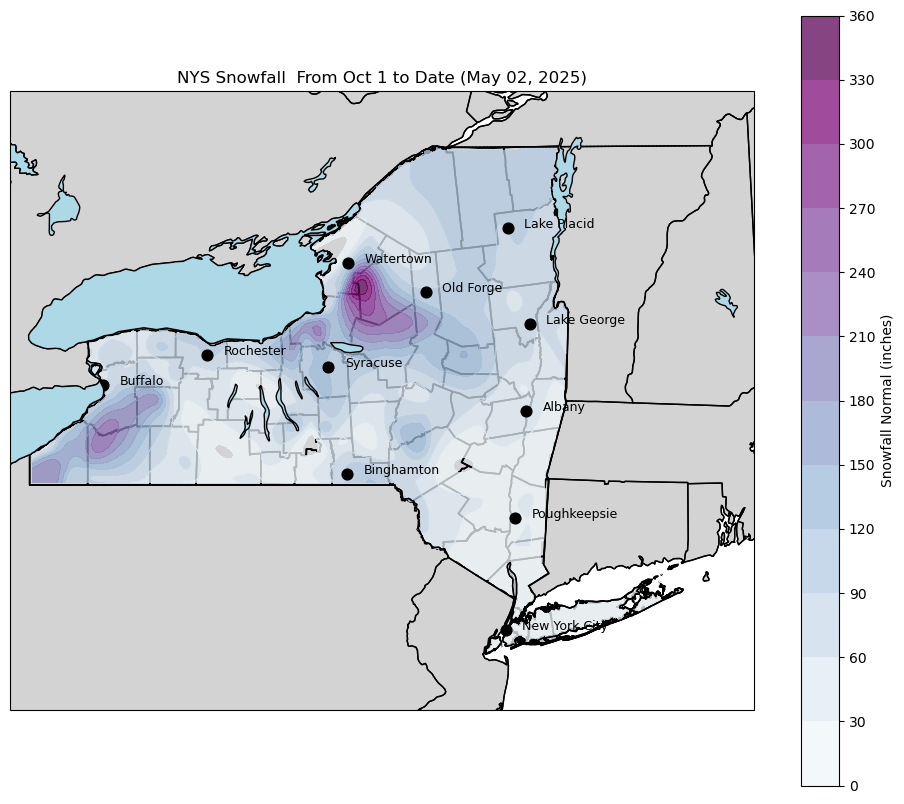

In [14]:
import pandas as pd
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
from shapely.geometry import Point
from matplotlib.ticker import MaxNLocator

# === Load and filter data ===  # Ensure this DataFrame is properly defined
currentdata = currentdata.dropna(subset=[' TotalSnowfall'])

# Load NYS shapefile
shapefile_path = 'Counties_Shoreline.shp'
gdf = gpd.read_file(shapefile_path).to_crs("EPSG:4326")  # Ensure correct CRS

# Create GeoDataFrame for snowfall normal data
snowfall_gdf = gpd.GeoDataFrame(
    currentdata,
    geometry=gpd.points_from_xy(currentdata.Longitude, currentdata.Latitude),
    crs="EPSG:4326"
)

# Extract coordinates and anomaly values
lats = snowfall_gdf['Latitude'].values
lons = snowfall_gdf['Longitude'].values
snowfall = snowfall_gdf[' TotalSnowfall'].values

# Define grid for contouring
lon_min, lon_max = -80, -71
lat_min, lat_max = 40, 45.5
lon_grid, lat_grid = np.meshgrid(
    np.linspace(lon_min, lon_max, 200),
    np.linspace(lat_min, lat_max, 200)
)

# Interpolate snowfall normal data
grid_snowfall_cubic = griddata((lons, lats), snowfall, (lon_grid, lat_grid), method="cubic")
grid_snowfall_nearest = griddata((lons, lats), snowfall, (lon_grid, lat_grid), method="nearest")
grid_snowfall = np.where(np.isnan(grid_snowfall_cubic), grid_snowfall_nearest, grid_snowfall_cubic)

# Apply Gaussian filter to smooth the interpolated grid
grid_snowfall_smoothed = gaussian_filter(grid_snowfall, sigma=1.0)  # Adjust sigma for more/less smoothing

# === Mask areas outside NYS ===
mask = np.zeros(grid_snowfall_smoothed.shape, dtype=bool)

# Iterate over NYS polygons to apply mask
for geom in gdf.geometry:
    for i, (lon, lat) in enumerate(zip(lon_grid.flatten(), lat_grid.flatten())):
        point = Point(lon, lat)
        if geom.contains(point):
            mask[np.unravel_index(i, mask.shape)] = True

# Apply the mask to snowfall normal data
grid_snowfall_smoothed[~mask] = np.nan

# === Plot the snowfall normal contour map ===
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Add shapefile boundary
gdf.plot(ax=ax, edgecolor="black", facecolor="none", linewidth=1.2, transform=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.STATES, edgecolor="black")
ax.add_feature(cfeature.COASTLINE, edgecolor="black")
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.LAKES, edgecolor="black", facecolor="lightblue")

# Define contour levels
levels = np.arange(0, np.nanmax(grid_snowfall_smoothed) + 30, 30)

# Contour plot of smoothed snowfall normal data (masked)
contour = ax.contourf(lon_grid, lat_grid, grid_snowfall_smoothed, levels=levels, cmap="BuPu", alpha=0.75)

# Create a colorbar
cbar = plt.colorbar(contour, ax=ax, orientation="vertical", label="Snowfall Normal (inches)")
cbar.set_ticks(levels)  # Set colorbar ticks to match contour intervals

# === Add Cities to the Map ===
cities = {
    "New York City": (-74.0060, 40.7128),
    "Buffalo": (-78.8784, 42.8864),
    "Rochester": (-77.6120, 43.1566),
    "Syracuse": (-76.1474, 43.0481),
    "Albany": (-73.7562, 42.6526),
    "Binghamton": (-75.9179, 42.0987),
    "Lake George": (-73.7145, 43.4291),
    "Lake Placid": (-73.9802, 44.2795),
    "Poughkeepsie": (-73.8931, 41.7096),
    "Old Forge": (-74.9735, 43.7101),
    "Watertown": (-75.9097, 43.9726)
}

for city, (lon, lat) in cities.items():
    ax.scatter(lon, lat, color="black", marker="o", s=60, transform=ccrs.PlateCarree())
    ax.text(lon + 0.2, lat, city, fontsize=9, ha="left", transform=ccrs.PlateCarree())

# Title
ax.set_title(f"NYS Snowfall  From Oct 1 to Date ({datetime.now().strftime('%B %d, %Y')})")
# Save the figure before displaying it
plt.savefig("NYS_Snowfall_Normals.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
today_normal.columns
today_normal[' TotalSnowfall']=today_normal['CUMULATIVE_SNOW_NORMAL']
today_normal['Longitude']=today_normal['LONGITUDE']
today_normal['Latitude']=today_normal['LATITUDE']

/tmp/ipykernel_450272/1423348806.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  today_normal[' TotalSnowfall']=today_normal['CUMULATIVE_SNOW_NORMAL']
/tmp/ipykernel_450272/1423348806.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  today_normal['Longitude']=today_normal['LONGITUDE']
/tmp/ipykernel_450272/1423348806.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documenta

### Snowfall Anomaly Maps

NaN values in anomaly grid after processing: 28962


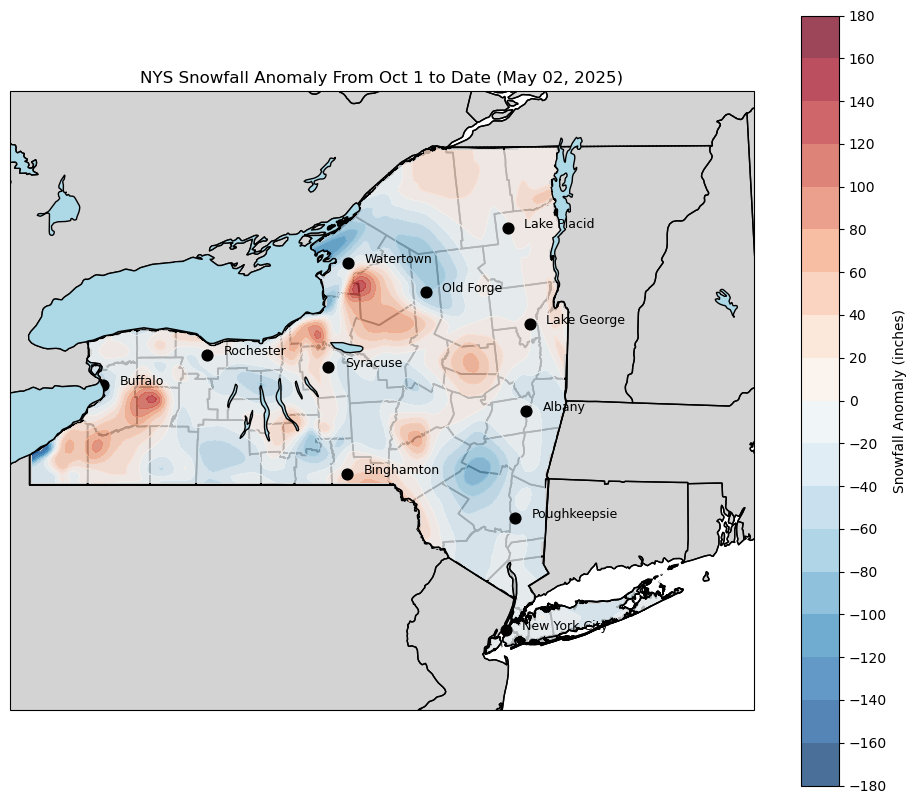

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
from shapely.geometry import Point
from datetime import datetime

# === Load the snowfall datasets ===
currentdata = currentdata.dropna(subset=['TotalSnowfall'])
normalsdata = today_normal.dropna(subset=['CUMULATIVE_SNOW_NORMAL'])

# Load NYS shapefile
shapefile_path = 'Counties_Shoreline.shp'
gdf = gpd.read_file(shapefile_path).to_crs("EPSG:4326")

# Convert to GeoDataFrame
current_gdf = gpd.GeoDataFrame(
    currentdata, geometry=gpd.points_from_xy(currentdata.Longitude, currentdata.Latitude), crs="EPSG:4326"
)
normals_gdf = gpd.GeoDataFrame(
    normalsdata, geometry=gpd.points_from_xy(normalsdata.Longitude, normalsdata.Latitude), crs="EPSG:4326"
)

# Extract coordinates and snowfall values
lats_curr, lons_curr, snowfall_curr = current_gdf.Latitude.values, current_gdf.Longitude.values, current_gdf.TotalSnowfall.values
lats_norm, lons_norm, snowfall_norm = normals_gdf.Latitude.values, normals_gdf.Longitude.values, normalsdata.CUMULATIVE_SNOW_NORMAL.values

# === Create a high-resolution grid ===
grid_res = 200
lon_min, lon_max = -80, -71
lat_min, lat_max = 40, 45.5
lon_grid, lat_grid = np.meshgrid(
    np.linspace(lon_min, lon_max, grid_res),
    np.linspace(lat_min, lat_max, grid_res)
)

# === Interpolate Normal Snowfall at All Points ===
grid_normals_cubic = griddata((lons_norm, lats_norm), snowfall_norm, (lon_grid, lat_grid), method="cubic")
grid_normals_nearest = griddata((lons_norm, lats_norm), snowfall_norm, (lon_grid, lat_grid), method="nearest")
grid_normals = np.where(np.isnan(grid_normals_cubic), grid_normals_nearest, grid_normals_cubic)

# === Interpolate Current Snowfall at All Points ===
grid_snowfall_cubic = griddata((lons_curr, lats_curr), snowfall_curr, (lon_grid, lat_grid), method="cubic")
grid_snowfall_nearest = griddata((lons_curr, lats_curr), snowfall_curr, (lon_grid, lat_grid), method="nearest")
grid_snowfall = np.where(np.isnan(grid_snowfall_cubic), grid_snowfall_nearest, grid_snowfall_cubic)

# === Compute the Anomaly (Current - Normal) ===
grid_anomaly = grid_snowfall - grid_normals

# Apply Gaussian smoothing to the anomaly grid
grid_anomaly_smoothed = gaussian_filter(grid_anomaly, sigma=1.0)

# === Mask areas outside NYS ===
mask = np.zeros(grid_anomaly_smoothed.shape, dtype=bool)

# Iterate over NYS polygons to apply mask
for geom in gdf.geometry:
    for i, (lon, lat) in enumerate(zip(lon_grid.flatten(), lat_grid.flatten())):
        point = Point(lon, lat)
        if geom.contains(point):
            mask[np.unravel_index(i, mask.shape)] = True

# Apply the mask to anomaly data
grid_anomaly_smoothed[~mask] = np.nan

# === Debugging: Check NaN count after processing ===
print(f"NaN values in anomaly grid after processing: {np.sum(np.isnan(grid_anomaly_smoothed))}")

# === Define symmetric contour levels centered around zero ===
abs_max = max(abs(np.nanmin(grid_anomaly_smoothed)), abs(np.nanmax(grid_anomaly_smoothed)))
rounded_max = np.ceil(abs_max / 20) * 20  # Round up to nearest 10
levels = np.arange(-rounded_max, rounded_max + 20, 20)

# === Major Cities and Locations in NYS (for reference) ===
cities = {
    "New York City": (-74.0060, 40.7128),
    "Buffalo": (-78.8784, 42.8864),
    "Rochester": (-77.6120, 43.1566),
    "Syracuse": (-76.1474, 43.0481),
    "Albany": (-73.7562, 42.6526),
    "Binghamton": (-75.9179, 42.0987),
    "Lake George": (-73.7145, 43.4291),
    "Lake Placid": (-73.9802, 44.2795),
    "Poughkeepsie": (-73.8931, 41.7096),
    "Old Forge": (-74.9735, 43.7101),
    "Watertown": (-75.9097, 43.9726)
}

# === Plot the Snowfall Anomaly Map ===
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Add shapefile boundary
gdf.plot(ax=ax, edgecolor="black", facecolor="none", linewidth=1.2, transform=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.STATES, edgecolor="black")
ax.add_feature(cfeature.COASTLINE, edgecolor="black")
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.LAKES, edgecolor="black", facecolor="lightblue")

# Contour plot of smoothed anomaly data (masked)
contour = ax.contourf(lon_grid, lat_grid, grid_anomaly_smoothed, levels=levels, cmap="RdBu_r", alpha=0.75)

# Create a colorbar with the same levels
cbar = plt.colorbar(contour, ax=ax, orientation="vertical", label="Snowfall Anomaly (inches)")
cbar.set_ticks(levels)

# === Plot Major Cities and Locations ===
for city, (lon, lat) in cities.items():
    ax.scatter(lon, lat, color="black", marker="o", s=60, label=city, transform=ccrs.PlateCarree())
    ax.text(lon + 0.2, lat, city, fontsize=9, ha="left", transform=ccrs.PlateCarree())

# === Commented Out Station Plot ===
#for i, row in current_gdf.iterrows():
#ax.scatter(row['Longitude'], row['Latitude'], color="black", marker="x", edgecolor="white", s=30, transform=ccrs.PlateCarree())

# Title and legend
ax.set_title(f"NYS Snowfall Anomaly From Oct 1 to Date ({datetime.now().strftime('%B %d, %Y')})")
#plt.legend()

# Save the figure before displaying it
plt.savefig("NYS_Snowfall_Anomaly_2024-2025.png", dpi=300, bbox_inches="tight")

# Display the figure
plt.show()


plt.show()


### Calculating Percentage Anomalies

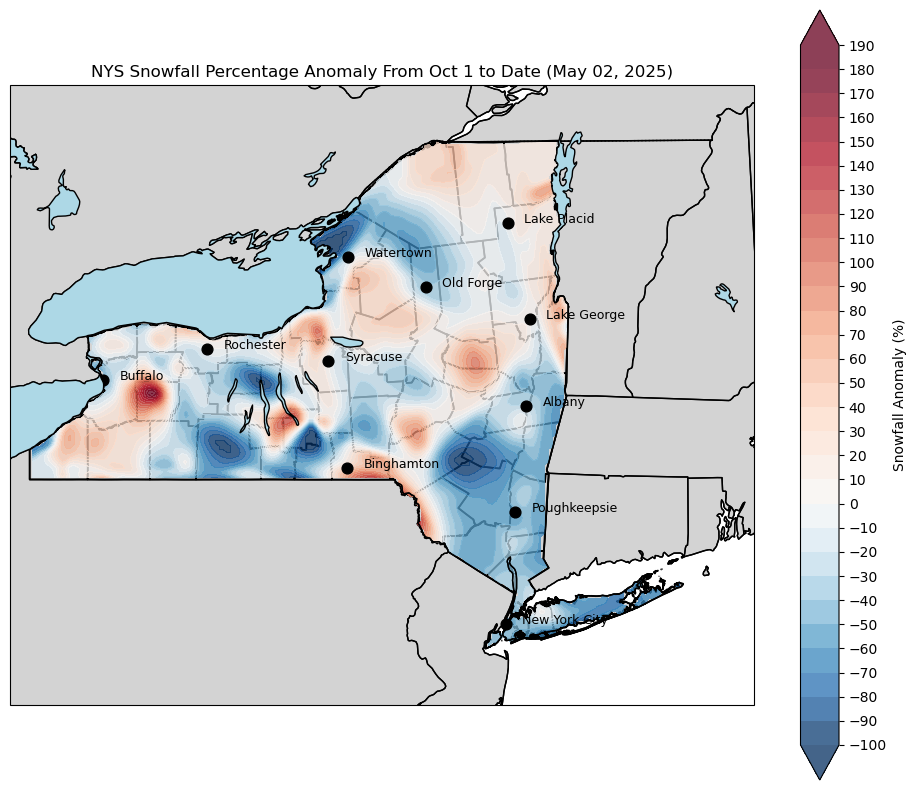

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
from shapely.geometry import Point
from datetime import datetime
import matplotlib.colors as mcolors

# === Load the snowfall datasets ===
currentdata = currentdata.dropna(subset=['TotalSnowfall'])
normalsdata = today_normal.dropna(subset=['CUMULATIVE_SNOW_NORMAL'])

# Load NYS shapefile
shapefile_path = 'Counties_Shoreline.shp'
gdf = gpd.read_file(shapefile_path).to_crs("EPSG:4326")

# Convert to GeoDataFrame
current_gdf = gpd.GeoDataFrame(
    currentdata, geometry=gpd.points_from_xy(currentdata.Longitude, currentdata.Latitude), crs="EPSG:4326"
)
normals_gdf = gpd.GeoDataFrame(
    normalsdata, geometry=gpd.points_from_xy(normalsdata.Longitude, normalsdata.Latitude), crs="EPSG:4326"
)

# Extract coordinates and snowfall values
lats_curr, lons_curr, snowfall_curr = current_gdf.Latitude.values, current_gdf.Longitude.values, current_gdf.TotalSnowfall.values
lats_norm, lons_norm, snowfall_norm = normals_gdf.Latitude.values, normals_gdf.Longitude.values, normalsdata.CUMULATIVE_SNOW_NORMAL.values

# === Create a high-resolution grid ===
grid_res = 200
lon_min, lon_max = -80, -71
lat_min, lat_max = 40, 45.5
lon_grid, lat_grid = np.meshgrid(
    np.linspace(lon_min, lon_max, grid_res),
    np.linspace(lat_min, lat_max, grid_res)
)

# === Interpolate Normal Snowfall at All Points ===
grid_normals_cubic = griddata((lons_norm, lats_norm), snowfall_norm, (lon_grid, lat_grid), method="cubic")
grid_normals_nearest = griddata((lons_norm, lats_norm), snowfall_norm, (lon_grid, lat_grid), method="nearest")
grid_normals = np.where(np.isnan(grid_normals_cubic), grid_normals_nearest, grid_normals_cubic)

# === Interpolate Current Snowfall at All Points ===
grid_snowfall_cubic = griddata((lons_curr, lats_curr), snowfall_curr, (lon_grid, lat_grid), method="cubic")
grid_snowfall_nearest = griddata((lons_curr, lats_curr), snowfall_curr, (lon_grid, lat_grid), method="nearest")
grid_snowfall = np.where(np.isnan(grid_snowfall_cubic), grid_snowfall_nearest, grid_snowfall_cubic)

# === Compute the Anomaly (Current - Normal) ===
grid_anomaly = grid_snowfall - grid_normals

# === Compute Percentage of Normal Anomaly ===
grid_percentage_anomaly = (grid_anomaly / grid_normals) * 100

# Apply Gaussian smoothing to the percentage anomaly grid
grid_percentage_anomaly_smoothed = gaussian_filter(grid_percentage_anomaly, sigma=1.0)

# === Mask areas outside NYS ===
mask = np.zeros(grid_percentage_anomaly_smoothed.shape, dtype=bool)

# Iterate over NYS polygons to apply mask
for geom in gdf.geometry:
    for i, (lon, lat) in enumerate(zip(lon_grid.flatten(), lat_grid.flatten())):
        point = Point(lon, lat)
        if geom.contains(point):
            mask[np.unravel_index(i, mask.shape)] = True

# Apply the mask to percentage anomaly data
grid_percentage_anomaly_smoothed[~mask] = np.nan

# Ensure anomalies below -100% are clamped
grid_percentage_anomaly_filled = np.clip(grid_percentage_anomaly_smoothed, -100, None)

# Define symmetric contour levels with -100% minimum
max_value = np.nanmax(grid_percentage_anomaly_filled)
levels = np.arange(-100, max_value + 10, 10)  # Step size of 20%

# Define colormap normalization centered at 100%
cmap = plt.cm.RdBu_r  # Reverse RdBu colormap for diverging effect
cmap.set_bad(color='lightgray')  # Color for NaN areas
norm = mcolors.TwoSlopeNorm(vmin=-100, vcenter=0, vmax=max_value)

# === Major Cities and Locations in NYS ===
cities = {
    "New York City": (-74.0060, 40.7128),
    "Buffalo": (-78.8784, 42.8864),
    "Rochester": (-77.6120, 43.1566),
    "Syracuse": (-76.1474, 43.0481),
    "Albany": (-73.7562, 42.6526),
    "Binghamton": (-75.9179, 42.0987),
    "Lake George": (-73.7145, 43.4291),
    "Lake Placid": (-73.9802, 44.2795),
    "Poughkeepsie": (-73.8931, 41.7096),
    "Old Forge": (-74.9735, 43.7101),
    "Watertown": (-75.9097, 43.9726)
}

# === Plot the Snowfall Anomaly Map ===
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Add shapefile boundary
gdf.plot(ax=ax, edgecolor="black", facecolor="none", linewidth=1.2, transform=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.STATES, edgecolor="black")
ax.add_feature(cfeature.COASTLINE, edgecolor="black")
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.LAKES, edgecolor="black", facecolor="lightblue")

# Contour plot of smoothed percentage anomaly data (masked)
contour = ax.contourf(lon_grid, lat_grid, grid_percentage_anomaly_filled, levels=levels, cmap=cmap, norm=norm, alpha=0.75, extend="both")

# Create a colorbar with the same levels
cbar = plt.colorbar(contour, ax=ax, orientation="vertical", label="Snowfall Anomaly (%)")
cbar.set_ticks(levels)

# === Plot Major Cities and Locations ===
for city, (lon, lat) in cities.items():
    ax.scatter(lon, lat, color="black", marker="o", s=60, transform=ccrs.PlateCarree())
    ax.text(lon + 0.2, lat, city, fontsize=9, ha="left", transform=ccrs.PlateCarree())

# Title
ax.set_title(f"NYS Snowfall Percentage Anomaly From Oct 1 to Date ({datetime.now().strftime('%B %d, %Y')})")

# Save the figure before displaying it
plt.savefig("NYS_Snowfall_Percent_Anomaly.png", dpi=300, bbox_inches="tight")

# Display the figure
plt.show()


##### Anomalies below -100% indicate missing data interpolation for those spots.

### Percentage of Normal

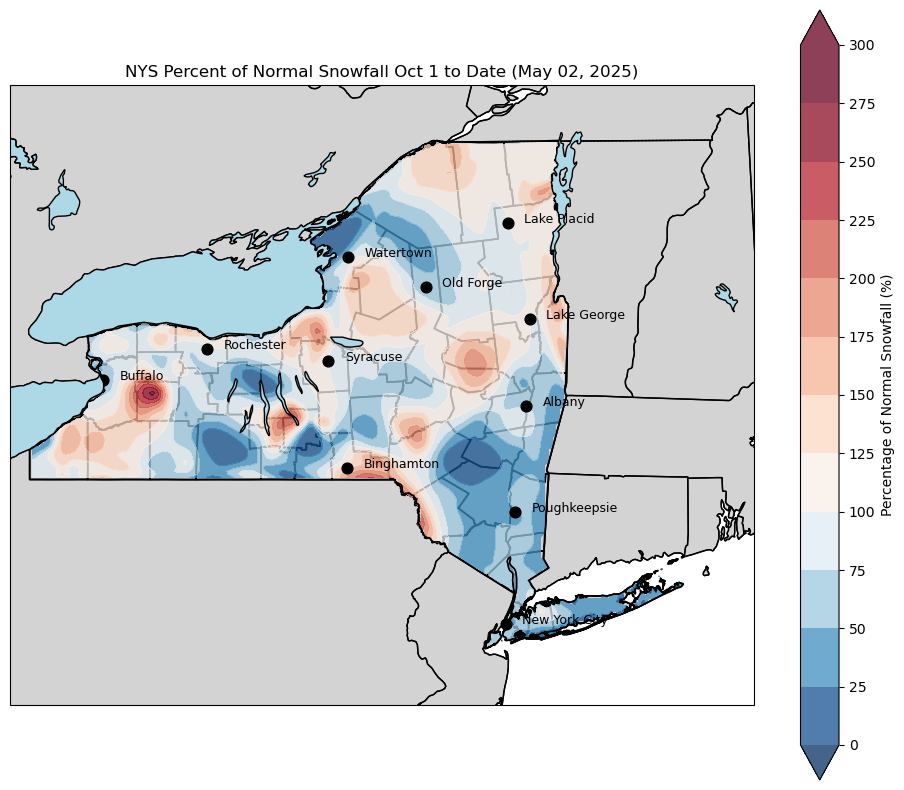

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import Point
from scipy.ndimage import gaussian_filter

# === Ensure Negative Percent Anomalies are Normalized to Positive Percentages ===
grid_percentage_of_normal = (grid_snowfall / grid_normals) * 100
grid_percentage_of_normal = np.clip(grid_percentage_of_normal, 0, None)  # Clamp values below 0 to 0

# Apply Gaussian smoothing to the percentage anomaly grid
grid_percentage_of_normal_smoothed = gaussian_filter(grid_percentage_of_normal, sigma=1.0)

# === Mask areas outside NYS ===
mask = np.zeros(grid_percentage_of_normal_smoothed.shape, dtype=bool)

for geom in gdf.geometry:
    for i, (lon, lat) in enumerate(zip(lon_grid.flatten(), lat_grid.flatten())):
        point = Point(lon, lat)
        if geom.contains(point):
            mask[np.unravel_index(i, mask.shape)] = True

grid_percentage_of_normal_smoothed[~mask] = np.nan

# === Define contour levels and plot ===
max_value = np.nanmax(grid_percentage_of_normal_smoothed)
min_value = np.nanmin(grid_percentage_of_normal_smoothed)
levels = np.arange(min_value, max_value + 25, 25)

# === Define Major Cities and Locations in NYS ===
cities = {
    "New York City": (-74.0060, 40.7128),
    "Buffalo": (-78.8784, 42.8864),
    "Rochester": (-77.6120, 43.1566),
    "Syracuse": (-76.1474, 43.0481),
    "Albany": (-73.7562, 42.6526),
    "Binghamton": (-75.9179, 42.0987),
    "Lake George": (-73.7145, 43.4291),
    "Lake Placid": (-73.9802, 44.2795),
    "Poughkeepsie": (-73.8931, 41.7096),
    "Old Forge": (-74.9735, 43.7101),
    "Watertown": (-75.9097, 43.9726)
}

# === Plot with Cartopy projection ===
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Add shapefile boundary and map features
gdf.plot(ax=ax, edgecolor="black", facecolor="none", linewidth=1.2, transform=ccrs.PlateCarree())
ax.add_feature(cfeature.STATES, edgecolor="black")
ax.add_feature(cfeature.COASTLINE, edgecolor="black")
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.LAKES, edgecolor="black", facecolor="lightblue")

# Define colormap and normalization
cmap = plt.cm.RdBu_r  # Reverse RdBu colormap for a diverging effect
cmap.set_bad(color='lightgray')  # Color for NaN areas
norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=100, vmax=max_value)

# Contour plot with normalization applied
contour = ax.contourf(lon_grid, lat_grid, grid_percentage_of_normal_smoothed, levels=levels, cmap=cmap, norm=norm, alpha=0.75, extend="both")

# Create a colorbar with the same levels
cbar = plt.colorbar(contour, ax=ax, orientation="vertical", label="Percentage of Normal Snowfall (%)")
cbar.set_ticks(levels)

# === Plot Major Cities and Locations ===
for city, (lon, lat) in cities.items():
    ax.scatter(lon, lat, color="black", marker="o", s=60, transform=ccrs.PlateCarree())
    ax.text(lon + 0.2, lat, city, fontsize=9, ha="left", transform=ccrs.PlateCarree())

# Title
ax.set_title(f"NYS Percent of Normal Snowfall Oct 1 to Date ({datetime.now().strftime('%B %d, %Y')})")

# Save the figure before displaying it
plt.savefig("NYS_Snowfall_PercentofNormal_2024-2025.png", dpi=300, bbox_inches="tight")

# Display the figure
plt.show()


### The anomalies of less than 25% in this plot could be due to missing data for those regions. Sorry!

# Enjoy The Maps!